# Session 1: Lineare Programmierung und Maximum Flow
### Lern-Notebook — ausführlich erklärt

---

## Was ist ein lineares Programm (LP)?

Ein **Optimierungsproblem** hat immer drei Bestandteile:

1. **Entscheidungsvariablen** — Werte die wir frei wählen können (z.B. Budget für Projekt A vs. B)
2. **Zielfunktion** — was wir maximieren oder minimieren wollen (z.B. Gesamtnutzen)
3. **Constraints** — Einschränkungen die erfüllt sein müssen (z.B. Gesamtbudget ≤ 100)

Ein LP ist ein Optimierungsproblem bei dem **sowohl Zielfunktion als auch alle Constraints linear** sind — keine Quadrate, keine Produkte von Variablen, nur Terme wie `3*x1 + 2*x2`.

**Warum nützlich?** LPs lassen sich garantiert und effizient lösen. Es gibt immer genau ein globales Optimum.

---

## Was ist `cvxpy`?

`cvxpy` ist eine Python-Bibliothek zum Beschreiben und Lösen von Optimierungsproblemen. Man schreibt das Problem fast wie in der Mathematik, und cvxpy ruft im Hintergrund einen Solver auf.


In [2]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import time

---
## Aufgabe 1

> **Originalaufgabe (Prof):**
>
> Create a short Python script that solves a small linear program of your choice. Your script must:
> - define decision variables
> - define a linear objective
> - define at least two linear constraints
> - solve the problem
> - print the optimal objective value and the optimal decision variables
>
> In addition, briefly explain in comments what the model represents.

---

### Was wird hier verlangt?

Wir sollen ein eigenes kleines LP bauen um cvxpy kennenzulernen. Wir nutzen das Budgetbeispiel aus dem Tutorial:

**Das Problem:** Zwei Projekte P1 und P2, wir haben 100 Einheiten Budget.
- P1 bringt 8 Einheiten Nutzen pro Budget-Einheit
- P2 bringt 5 Einheiten Nutzen pro Budget-Einheit
- P1 darf maximal 60 bekommen, P2 muss mindestens 20 bekommen

**Mathematisch:**
$$\max_{x_1, x_2} \; 8x_1 + 5x_2 \quad \text{s.t.} \quad x_1+x_2 \leq 100, \; x_1 \leq 60, \; x_2 \geq 20, \; x_1,x_2 \geq 0$$

**Intuitive Lösung:** Da P1 mehr Nutzen bringt (8 > 5), füllen wir P1 zuerst bis zur Grenze (60). Rest geht an P2 (40). Gesamtnutzen: 8·60 + 5·40 = **680**.


In [3]:
# Budgetplanung: zwei Projekte P1 und P2

# Entscheidungsvariablen: cp.Variable() = eine reelle Zahl die cvxpy optimiert
x1 = cp.Variable()  # Budget fuer P1
x2 = cp.Variable()  # Budget fuer P2

# Zielfunktion: Gesamtnutzen maximieren
objective = cp.Maximize(8*x1 + 5*x2)

# Constraints: Liste aller Bedingungen
constraints = [
    x1 + x2 <= 100,  # Gesamtbudget
    x1 <= 60,         # Obergrenze P1
    x2 >= 20,         # Mindestbudget P2
    x1 >= 0,
    x2 >= 0,
]

# Problem loesen
prob = cp.Problem(objective, constraints)
prob.solve()

# .value gibt den optimalen Wert der Variable aus
print(f"Status: {prob.status}")  # 'optimal' = Loesung gefunden
print(f"Optimaler Gesamtnutzen: {prob.value:.2f}")
print(f"Budget P1 (x1): {x1.value:.2f}")
print(f"Budget P2 (x2): {x2.value:.2f}")

Status: optimal
Optimaler Gesamtnutzen: 680.00
Budget P1 (x1): 60.00
Budget P2 (x2): 40.00


---
## Aufgabe 2

> **Originalaufgabe (Prof):**
>
> Consider the directed graph with node set V = {1,2,3,4,5,6}, source s=1, sink t=6,
> and directed edges with capacities:
> (1,2):7, (1,3):6, (2,3):2, (2,4):5, (2,5):3, (3,5):6, (5,4):3, (4,6):6, (5,6):8
>
> Implement a Python program that formulates the maximum flow problem as a linear program.
> Your implementation must:
> - introduce one flow variable for each directed edge
> - maximize the total flow from source to sink
> - enforce capacity constraints
> - enforce nonnegativity of all flows
> - enforce flow conservation at all internal nodes

---

### Was ist Maximum Flow?

Stell dir ein **Rohrnetzwerk** vor:
- **Knoten** = Verbindungspunkte
- **Kanten** = Rohre mit Richtung und maximaler Kapazität (wie viel Wasser passt durch)
- **Quelle (source)** = Knoten 1, wo Wasser reinkommt
- **Senke (sink)** = Knoten 6, wo Wasser rausfließt

**Frage:** Wie viel Wasser kann maximal von Knoten 1 zu Knoten 6 fließen?

### LP-Formulierung — Schritt für Schritt

**Entscheidungsvariablen:** Eine Variable $f_{ij}$ pro Kante = der Fluss auf dieser Kante.

**Kapazitaetsbeschraenkung:** Jeder Fluss muss zwischen 0 und der Kapazitaet liegen:
$$0 \leq f_{ij} \leq u_{ij}$$

**Flusserhaltung (Flow Conservation):** An jedem internen Knoten muss Einfluss = Ausfluss sein (wie Kirchhoffs Knotengesetz). Fuer Knoten 2:
$$f_{12} = f_{23} + f_{24} + f_{25}$$

**Zielfunktion:** Maximiere den Gesamtabfluss aus der Quelle:
$$\max \; f_{12} + f_{13}$$


In [4]:
# Kantenliste: (von-Knoten, zu-Knoten, Kapazitaet)
edges = [
    (1, 2, 7), (1, 3, 6),
    (2, 3, 2), (2, 4, 5), (2, 5, 3),
    (3, 5, 6),
    (5, 4, 3), (4, 6, 6), (5, 6, 8),
]

source = 1
sink = 6
internal_nodes = [2, 3, 4, 5]  # Knoten wo Flusserhaltung gilt
m = len(edges)                 # 9 Kanten = 9 Variablen

# Eine Flussvariable pro Kante, nonneg=True setzt f >= 0 automatisch
f = cp.Variable(m, nonneg=True)
capacities = np.array([cap for _, _, cap in edges])

constraints = []

# 1. Kapazitaetsbeschraenkung
constraints.append(f <= capacities)

# 2. Flusserhaltung an jedem internen Knoten
for node in internal_nodes:
    inflow  = cp.sum([f[i] for i, (u, v, _) in enumerate(edges) if v == node])
    outflow = cp.sum([f[i] for i, (u, v, _) in enumerate(edges) if u == node])
    constraints.append(inflow - outflow == 0)

# 3. Zielfunktion: Gesamtabfluss aus der Quelle
source_outflow = cp.sum([f[i] for i, (u, v, _) in enumerate(edges) if u == source])
objective = cp.Maximize(source_outflow)

prob = cp.Problem(objective, constraints)
prob.solve()

print(f"Status: {prob.status}")
print(f"Maximaler Gesamtfluss: {prob.value:.4f}")

Status: optimal
Maximaler Gesamtfluss: 13.0000


---
## Aufgabe 3

> **Originalaufgabe (Prof):**
>
> Solve the linear program numerically. Report:
> - the optimal objective value
> - the optimal flow on each edge
> - whether each edge is saturated or not
> - whether flow conservation is satisfied up to numerical tolerance
>
> Add a short routine that checks the balance equation at every node automatically.

---

### Erklaerung

**Gesaettigte Kante (saturated):** Fluss ist genau gleich der Kapazitaet — das ist ein **Engpass**.

**Numerische Toleranz:** Computer rechnen nicht exakt. Eine Loesung die eigentlich 6.0 sein soll koennte als 6.0000000001 rauskommen. Deshalb pruefen wir: ist |f - u| <= 1e-6?

**Flusserhaltung pruefen:** Einfluss - Ausfluss sollte 0 sein. Numerisch: ist |Einfluss - Ausfluss| <= 1e-6?


In [5]:
f_opt = f.value
eps = 1e-6

print("Optimaler Fluss pro Kante:")
print("=" * 52)
print(f"{'Kante':<10} {'Fluss':>8} {'Kapazitaet':>12} {'Gesaettigt?':>13}")
print("-" * 52)
for i, (u, v, cap) in enumerate(edges):
    saturated = abs(f_opt[i] - cap) <= eps
    print(f"({u} -> {v}){'':2} {f_opt[i]:>8.4f} {cap:>12} {'JA <- Engpass' if saturated else 'nein':>13}")
print()

print("Flusserhaltung an internen Knoten:")
for node in internal_nodes:
    inflow  = sum(f_opt[i] for i, (u, v, _) in enumerate(edges) if v == node)
    outflow = sum(f_opt[i] for i, (u, v, _) in enumerate(edges) if u == node)
    balance = inflow - outflow
    ok = abs(balance) <= eps
    print(f"  Knoten {node}: Einfluss={inflow:.4f}, Ausfluss={outflow:.4f}, "
          f"Differenz={balance:.2e}  {'OK' if ok else 'FEHLER'}")

Optimaler Fluss pro Kante:
Kante         Fluss   Kapazitaet   Gesaettigt?
----------------------------------------------------
(1 -> 2)     7.0000            7 JA <- Engpass
(1 -> 3)     6.0000            6 JA <- Engpass
(2 -> 3)     0.0000            2          nein
(2 -> 4)     4.3733            5          nein
(2 -> 5)     2.6267            3          nein
(3 -> 5)     6.0000            6 JA <- Engpass
(5 -> 4)     1.2205            3          nein
(4 -> 6)     5.5938            6          nein
(5 -> 6)     7.4062            8          nein

Flusserhaltung an internen Knoten:
  Knoten 2: Einfluss=7.0000, Ausfluss=7.0000, Differenz=8.88e-16  OK
  Knoten 3: Einfluss=6.0000, Ausfluss=6.0000, Differenz=0.00e+00  OK
  Knoten 4: Einfluss=5.5938, Ausfluss=5.5938, Differenz=-8.88e-16  OK
  Knoten 5: Einfluss=8.6267, Ausfluss=8.6267, Differenz=0.00e+00  OK


---
## Aufgabe 4

> **Originalaufgabe (Prof):**
>
> Investigate how the optimal maximum flow changes when one bottleneck capacity varies.
> Choose one of the following edges: (4,6), (5,6), (1,2).
> Then:
> - vary its capacity over a suitable integer range
> - solve the linear program for every value
> - plot capacity versus optimal maximum flow
> - comment on intervals where the objective changes and where it stays constant
>
> Your code should be written so that capacities can be changed without rewriting the full model.

---

### Erklaerung: Sensitivitaetsanalyse

Wir variieren die Kapazitaet einer Kante systematisch und beobachten wie sich der Maximalfluss aendert.

**Erwartetes Verhalten:**
- Solange die Kante ein Engpass ist, steigt der Fluss mit der Kapazitaet
- Irgendwann wird eine andere Kante zum neuen Engpass — ab dann bleibt die Kurve **flach**
- Der Maximalfluss ist immer monoton nicht-abnehmend (mehr Kapazitaet kann nie schaden)

**Warum praktisch wichtig?** In echten Netzwerken (Strassen, Datenleitungen) zeigt das wo ein Ausbau am meisten bringt.


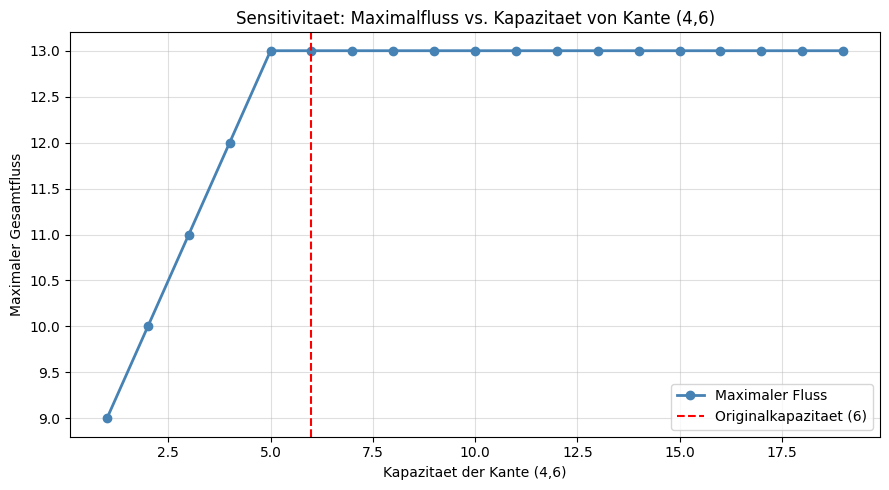

Beobachtung: Die Kurve steigt bis ein anderer Engpass aktiv wird — dann wird sie flach.


In [6]:
def solve_max_flow(edges_list):
    """Loest Max-Flow LP fuer eine gegebene Kantenliste."""
    m = len(edges_list)
    f_var = cp.Variable(m, nonneg=True)
    caps = np.array([cap for _, _, cap in edges_list])
    cons = [f_var <= caps]
    for node in internal_nodes:
        inflow  = cp.sum([f_var[i] for i, (u, v, _) in enumerate(edges_list) if v == node])
        outflow = cp.sum([f_var[i] for i, (u, v, _) in enumerate(edges_list) if u == node])
        cons.append(inflow - outflow == 0)
    src_out = cp.sum([f_var[i] for i, (u, v, _) in enumerate(edges_list) if u == source])
    return cp.Problem(cp.Maximize(src_out), cons).solve()

# Wir waehlen Kante (4,6) — eine gesaettigte Kante laut Aufgabe 3
target_idx = next(i for i, (u, v, _) in enumerate(edges) if u == 4 and v == 6)

cap_range = range(1, 20)
flow_values = []
for cap in cap_range:
    mod = list(edges)
    u, v, _ = mod[target_idx]
    mod[target_idx] = (u, v, cap)  # Kapazitaet ersetzen ohne Modell neu zu schreiben
    flow_values.append(solve_max_flow(mod))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(cap_range), flow_values, marker='o', linewidth=2, color='steelblue', label='Maximaler Fluss')
ax.axvline(x=edges[target_idx][2], color='red', linestyle='--',
           label=f'Originalkapazitaet ({edges[target_idx][2]})')
ax.set_xlabel('Kapazitaet der Kante (4,6)')
ax.set_ylabel('Maximaler Gesamtfluss')
ax.set_title('Sensitivitaet: Maximalfluss vs. Kapazitaet von Kante (4,6)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print("Beobachtung: Die Kurve steigt bis ein anderer Engpass aktiv wird — dann wird sie flach.")

---
## Aufgabe 5

> **Originalaufgabe (Prof):**
>
> Implement a simple heuristic that repeatedly augments flow along any available
> source-to-sink path until no further path can be found. Then compare:
> - the total flow obtained by the heuristic
> - the true optimum from the linear program
> - the runtime for both methods on this small instance
>
> Briefly discuss why optimization based modeling is preferable when correctness matters.

---

### Erklaerung: Greedy-Heuristik

**Greedy** (gierig) = bei jeder Entscheidung die lokal beste Option waehlen, ohne in die Zukunft zu schauen.

**Unser Algorithmus:**
1. Suche einen beliebigen Pfad von Quelle zu Senke (per BFS = Breitensuche)
2. Schicke so viel Fluss wie moeglich durch diesen Pfad (limitiert durch die engste Kante)
3. Reduziere Restkapazitaeten entsprechend
4. Wiederhole bis kein Pfad mehr existiert

**BFS (Breitensuche)** = sucht einen Pfad ebenenweise: erst alle direkten Nachbarn, dann deren Nachbarn usw. Findet immer *einen* Pfad, aber nicht unbedingt den besten.

**Problem:** Ohne Rueckwaertskanten kann der Algorithmus sich selbst blockieren und das Optimum verpassen.

**LP ist besser weil:** es alle moeglichen Flussverteilungen gleichzeitig beruecksichtigt und das garantierte globale Optimum findet.


In [7]:
def greedy_max_flow(edges, source, sink):
    """Naive Greedy-Heuristik ohne Rueckwaertskanten."""
    residual  = defaultdict(float)
    neighbors = defaultdict(set)
    for u, v, cap in edges:
        residual[(u, v)] += cap
        neighbors[u].add(v)

    total_flow = 0.0
    while True:
        # BFS: Pfad von source zu sink suchen
        queue = deque([(source, [source])])
        visited, path = {source}, None
        while queue and path is None:
            node, cur = queue.popleft()
            for nb in neighbors[node]:
                if nb not in visited and residual[(node, nb)] > 1e-9:
                    new = cur + [nb]
                    if nb == sink:
                        path = new; break
                    visited.add(nb)
                    queue.append((nb, new))
        if path is None:
            break
        # Engpasskapazitaet auf diesem Pfad
        bottleneck = min(residual[(path[i], path[i+1])] for i in range(len(path)-1))
        for i in range(len(path)-1):
            residual[(path[i], path[i+1])] -= bottleneck
        total_flow += bottleneck
    return total_flow

t0 = time.perf_counter()
greedy_result = greedy_max_flow(edges, source, sink)
t_greedy = time.perf_counter() - t0

t0 = time.perf_counter()
lp_result = solve_max_flow(edges)
t_lp = time.perf_counter() - t0

print(f"{'Methode':<15} {'Fluss':>8} {'Laufzeit':>12}")
print("-" * 38)
print(f"{'Greedy':<15} {greedy_result:>8.4f} {t_greedy*1000:>10.2f} ms")
print(f"{'LP (cvxpy)':<15} {lp_result:>8.4f} {t_lp*1000:>10.2f} ms")
print()
print("Fazit: Das LP garantiert das globale Optimum. Der Greedy gibt keine Garantie.")
print("Fuer korrektheitskritische Anwendungen ist LP-Modellierung klar ueberlegen.")

Methode            Fluss     Laufzeit
--------------------------------------
Greedy           13.0000       0.20 ms
LP (cvxpy)       13.0000       6.08 ms

Fazit: Das LP garantiert das globale Optimum. Der Greedy gibt keine Garantie.
Fuer korrektheitskritische Anwendungen ist LP-Modellierung klar ueberlegen.
